In [13]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

In [14]:
# Load dataset
df = pd.read_excel("energy_data.xlsx")

# Rename columns for simplicity
df.columns = [
    "date", "fossil_prod", "nuclear_prod", "renewable_prod", "total_prod",
    "imports", "exports", "net_imports", "stock_change",
    "fossil_cons", "nuclear_cons", "renewable_cons", "total_cons"
]

# Convert date, coercing errors to NaT
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Drop rows where 'date' is NaT (which were the invalid date entries)
df = df.dropna(subset=["date"])

# Sort values
df = df.sort_values("date")

# Drop remaining missing values after handling date issues
df = df.dropna()

print(df.head())

         date fossil_prod nuclear_prod renewable_prod total_prod   imports  \
11 1973-01-01    4.932632     0.068103       0.219839   5.220574   1.17308   
12 1973-02-01    4.729582     0.064634        0.19733   4.991545  1.168005   
13 1973-03-01    4.946902     0.072494       0.218686   5.238082  1.309473   
14 1973-04-01    4.716271      0.06407        0.20933   4.989672  1.085169   
15 1973-05-01    4.956995     0.062111       0.215982   5.235087  1.162804   

     exports net_imports stock_change fossil_cons nuclear_cons renewable_cons  \
11  0.125781    1.047299     0.771858    6.747651     0.068103       0.219839   
12  0.120883    1.047122     0.390129    6.163095     0.064634        0.19733   
13   0.13995    1.169523     -0.06764    6.044647     0.072494       0.218686   
14  0.194185    0.890984    -0.110067    5.493184      0.06407        0.20933   
15  0.196775    0.966029    -0.305335    5.613551     0.062111       0.215982   

   total_cons  
11   7.039731  
12   6.42879

# EDA Analysis

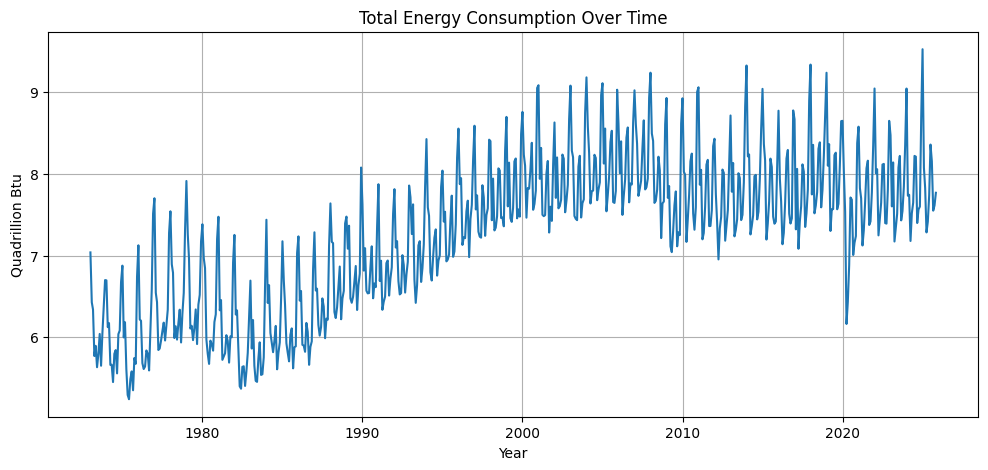

In [15]:
# 1. Total Consumption Trend

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["total_cons"])
plt.title("Total Energy Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Quadrillion Btu")
plt.grid()
plt.show()

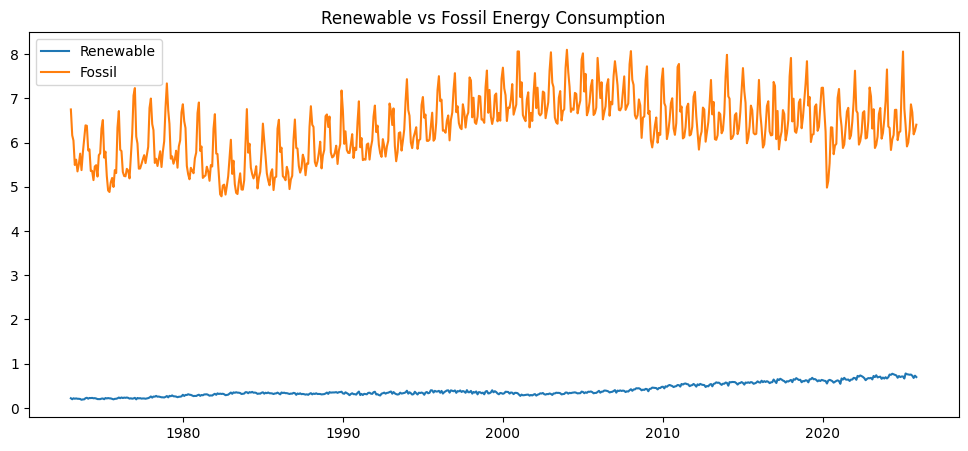

In [16]:
# 2. Renewable vs Fossil

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["renewable_cons"], label="Renewable")
plt.plot(df["date"], df["fossil_cons"], label="Fossil")
plt.legend()
plt.title("Renewable vs Fossil Energy Consumption")
plt.show()

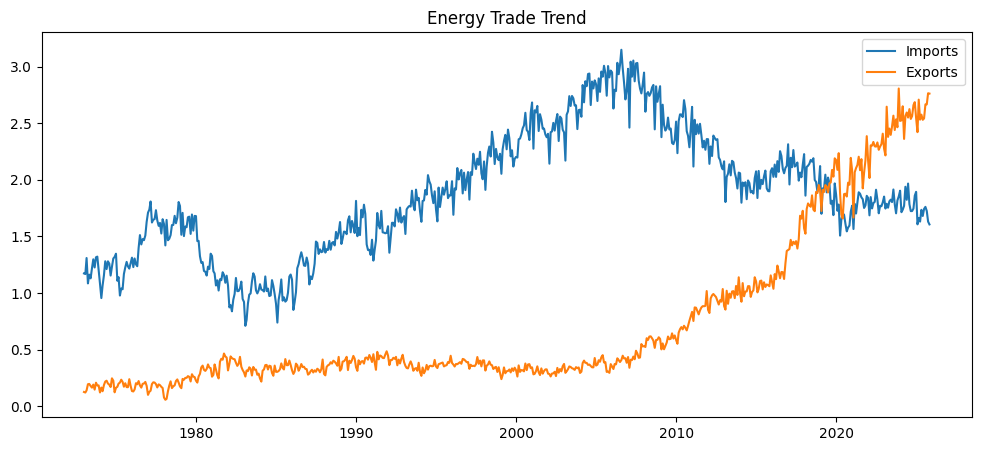

In [17]:
# 3. Imports vs Exports

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["imports"], label="Imports")
plt.plot(df["date"], df["exports"], label="Exports")
plt.legend()
plt.title("Energy Trade Trend")
plt.show()

# Train - Test Split

In [18]:
train_size = int(len(df)*0.85)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

# ARIMA Model

In [20]:
train_series = train.set_index("date")["total_cons"].astype(float)
test_series = test.set_index("date")["total_cons"].astype(float)

model = ARIMA(train_series, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

In [21]:
#Evaluation

mae = mean_absolute_error(test_series, forecast)
rmse = np.sqrt(((test_series - forecast)**2).mean())

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.4502918776367392
RMSE: 0.5845714055825869


# Prophet Model

In [25]:
prophet_df = df.rename(columns={
    'date': 'ds',
    'total_cons': 'y' # Corrected column name from 'total_consumption' to 'total_cons'
})

model_prophet = Prophet()
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
forecast_prophet = model_prophet.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


# Model Comparision

In [27]:
forecast_test = forecast_prophet.tail(len(test))

mae_prophet = mean_absolute_error(test['total_cons'], forecast_test['yhat'])
rmse_prophet = np.sqrt(((test['total_cons'] - forecast_test['yhat'])**2).mean())

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 0.22213371497896373
Prophet RMSE: 0.5568207966486924


# Multi-Year Forcast (5 Years)

In [28]:
final_model = Prophet()
final_model.fit(prophet_df)

future_5y = final_model.make_future_dataframe(periods=60, freq='MS')
forecast_5y = final_model.predict(future_5y)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


# Scenario-Based Modeling

In [29]:
scenario = forecast_5y[['ds','yhat']].tail(60).copy()
scenario.columns = ['date','baseline']

# Scenario 1: High Growth
scenario['high_growth'] = scenario['baseline'] * 1.08

# Scenario 2: Energy Efficiency
scenario['low_growth'] = scenario['baseline'] * 0.93

# Scenario 3: Shock Scenario
scenario['shock'] = scenario['baseline']
scenario.loc[scenario.index[:12], 'shock'] *= 0.90
scenario.loc[scenario.index[12:], 'shock'] *= 1.02

# Scenario Visualization

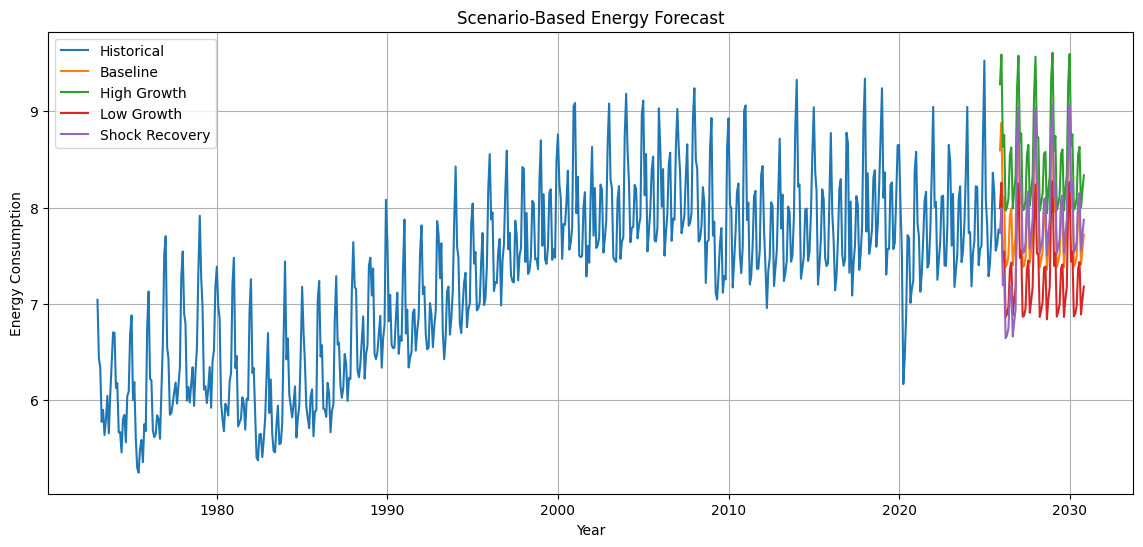

In [31]:
plt.figure(figsize=(14,6))

plt.plot(df['date'], df['total_cons'], label="Historical")
plt.plot(scenario['date'], scenario['baseline'], label="Baseline")
plt.plot(scenario['date'], scenario['high_growth'], label="High Growth")
plt.plot(scenario['date'], scenario['low_growth'], label="Low Growth")
plt.plot(scenario['date'], scenario['shock'], label="Shock Recovery")

plt.legend()
plt.title("Scenario-Based Energy Forecast")
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.grid()
plt.show()